<center><h1>Практическая работа №2</h1></center>

<center><h2>Тема работы: "Работа с Pandas"</h2></center>

<h5>Цель работы: научиться основным методам анализа данных на Python с использованием библиотеки Pandas, включая первичный анализ и очистку данных, фильтрацию, сортировку и группировку, вычисление новых признаков, выявление корреляций между числовыми признаками и составление кратких аналитических выводов.</h5>

<h5>Ход работы:</h5>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h5>1. Загрузка данных и изучение структуры.</h5>

In [14]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('cardekho.csv')

Saving cardekho.csv to cardekho (2).csv


In [15]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [16]:
df.info() # Информация о данных: типы столбцов и количество не-null значений

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [17]:
# Размерность датасета (строк, столбцов)
print(f"Размерность: {df.shape}")

# Названия столбцов
print(f"Столбцы: {df.columns.tolist()}")

Размерность: (8128, 12)
Столбцы: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']


<h5>2. Проверка пропусков и дубликатов. Очистка данных.</h5>

In [18]:
df.isnull().sum() # Проверка количества пропусков в каждом столбце

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),221
engine,221


In [19]:
# Проверка наличия дублирующихся строк (duplicated().sum())
duplicate_rows = df.duplicated().sum()
print(f"Количество дубликатов: {duplicate_rows}")

# Удаление дубликатов, если они есть
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print(f"Дубликаты удалены. Новый размер: {df.shape}")

Количество дубликатов: 1202
Дубликаты удалены. Новый размер: (6926, 12)


In [22]:
# Определение числовых и категориальных столбцов
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Обработка пропусков: заполнение числовых столбцов медианой
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Столбец '{col}' заполнен медианой: {median_val}")

# Обработка пропусков: заполнение категориальных столбцов модой
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Столбец '{col}' заполнен модой: '{mode_val}'")

In [21]:
# Проверка, что пропусков больше нет
print(f"Осталось пропусков: {df.isnull().sum().sum()}")

Осталось пропусков: 0


<h5>3. Анализ числовых и категориальных столбцов.</h5>

In [23]:
df.describe() # Статистика по числовым столбцам

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.464550,1425.398787,5.421600
std,4.078286,5.197670e+05,5.835810e+04,3.987878,487.026967,0.972171
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.440000,1248.000000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [24]:
# Топ-5 самых дорогих автомобилей (nlargest)
df.nlargest(5, 'selling_price')[['name', 'selling_price', 'year']]

,name,selling_price,year
170,Volvo XC90 T8 Excellence BSIV,10000000,2017
2938,BMW X7 xDrive 30d DPE,7200000,2020
4952,Audi A6 35 TFSI Matrix,6523000,2019
4950,Audi A6 35 TFSI Matrix,6223000,2019
136,Mercedes-Benz S-Class S 350 CDI,6000000,2017


In [25]:
# value_counts() - подсчет частоты значений в категориальных столбцах
print("Распределение по типу топлива:")
print(df['fuel'].value_counts())
print("\nРаспределение по типу продавца:")
print(df['seller_type'].value_counts())
print("\nРаспределение по типу коробки передач:")
print(df['transmission'].value_counts())
print("\nРаспределение по количеству владельцев:")
print(df['owner'].value_counts())

Распределение по типу топлива:
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

Распределение по типу продавца:
seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64

Распределение по типу коробки передач:
transmission
Manual       6342
Automatic     584
Name: count, dtype: int64

Распределение по количеству владельцев:
owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64


<h5>4. Фильтрация, сортировка и срезы данных.</h5>

In [26]:
# Фильтрация: автомобили с дизельным двигателем и пробегом менее 50,000 км
diesel_low_km = df[(df['fuel'] == 'Diesel') & (df['km_driven'] < 50000)]
print(f"Найдено дизельных авто с пробегом < 50,000 км: {len(diesel_low_km)}")
diesel_low_km.head()

Найдено дизельных авто с пробегом < 50,000 км: 729


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
22,Maruti Swift Dzire ZDI,2015,525000,40000,Diesel,Individual,Manual,First Owner,26.59,1248.0,74,5.0
34,Maruti Vitara Brezza LDi,2017,650000,16200,Diesel,Individual,Manual,First Owner,24.30,1248.0,88.5,5.0
45,Maruti Vitara Brezza VDi,2018,819999,32600,Diesel,Dealer,Manual,First Owner,24.30,1248.0,88.5,5.0
49,Mercedes-Benz B Class B180,2014,1450000,27800,Diesel,Dealer,Automatic,Second Owner,14.80,2143.0,120.7,5.0
50,Honda Amaze S Diesel,2015,425000,49800,Diesel,Dealer,Manual,First Owner,24.70,1498.0,98.63,5.0


In [27]:
# Сортировка: по году выпуска (по убыванию) и цене (по убыванию)
sorted_df = df.sort_values(by=['year', 'selling_price'], ascending=[False, False])
print("Топ-5 самых новых и дорогих автомобилей:")
sorted_df[['name', 'year', 'selling_price']].head()

Топ-5 самых новых и дорогих автомобилей:


,name,year,selling_price
2938,BMW X7 xDrive 30d DPE,2020,7200000
7661,Toyota Fortuner 2.8 4WD AT BSIV,2020,3200000
6638,Toyota Innova Crysta 2.4 ZX AT,2020,2300000
1978,Honda Civic ZX Diesel BSIV,2020,2125000
1984,Hyundai Creta 1.6 CRDi AT SX Plus,2020,1950000


In [32]:
# Срез данных
# loc - выборка по меткам (здесь: все строки, столбцы с 0 по 4)
print("Первые 5 строк, первые 5 столбцов (loc):")
print(df.loc[:, df.columns[:5]].head())

# iloc - выборка по индексам (здесь: строки 10-15, столбцы 0-3)
print("\nСтроки 10-15, столбцы 0-3 (iloc):")
df.iloc[10:16, 0:4]

Первые 5 строк, первые 5 столбцов (loc):
                           name  year  selling_price  km_driven    fuel
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol

Строки 10-15, столбцы 0-3 (iloc):


,name,year,selling_price,km_driven
10,Renault Duster 110PS Diesel RxL,2014,500000,68000
11,Maruti Zen LX,2005,92000,100000
12,Maruti Swift Dzire VDi,2009,280000,140000
13,Maruti Swift 1.3 VXi,2007,200000,80000
14,Maruti Wagon R LXI Minor,2009,180000,90000
15,Mahindra KUV 100 mFALCON G80 K8 5str,2016,400000,40000


<h5>5. Группировка данных по категориальным признакам и агрегация.</h5>

In [33]:
# groupby с агрегацией: средняя цена по типу топлива и коробке передач
grouped = df.groupby(['fuel', 'transmission'])['selling_price'].agg(['mean', 'count', 'max', 'min']).round(0)
print("Средняя, мин, макс цена и количество по типу топлива и коробке передач:")
grouped

Средняя, мин, макс цена и количество по типу топлива и коробке передач:


mean  count       max     min
fuel   transmission                                    
CNG    Manual         300500.0     56    545000   80000
Diesel Automatic     1788778.0    298   7200000  245000
       Manual         540677.0   3457   3200000   40000
LPG    Manual         200421.0     38    375000   54000
Petrol Automatic      810545.0    286  10000000   75000
       Manual         331128.0   2791   1520000   29999

In [34]:
# groupby: средний пробег по количеству владельцев
owner_km = df.groupby('owner')['km_driven'].mean().round(0).sort_values(ascending=False)
print("Средний пробег по количеству владельцев:")
owner_km

Средний пробег по количеству владельцев:


,km_driven
owner,
Fourth & Above Owner,107120.0
Third Owner,100180.0
Second Owner,90765.0
First Owner,61634.0
Test Drive Car,14631.0


In [35]:
# groupby: количество автомобилей и средняя цена по годам
year_stats = df.groupby('year').agg(
    car_count=('name', 'count'),
    avg_price=('selling_price', 'mean')
).round(0).sort_index(ascending=False)
print("Статистика по годам выпуска (первые 10):")
year_stats.head(10)

Статистика по годам выпуска (первые 10):


,car_count,avg_price
year,,
2020,63,888349.0
2019,347,949669.0
2018,608,866377.0
2017,808,732420.0
2016,693,653180.0
2015,681,589178.0
2014,581,511859.0
2013,562,451502.0
2012,604,351387.0


<h5>6. Корреляция между числовыми признаками и визуализация.</h5>

In [40]:
# Предварительная обработка столбца max_power (преобразование в числовой тип)
df['max_power'] = df['max_power'].astype(str).str.replace(' bhp', '', regex=False)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['max_power'] = df['max_power'].fillna(df['max_power'].median())

# Выбор числовых столбцов для корреляции
numeric_df = df.select_dtypes(include=[np.number])

# Расчет корреляционной матрицы (df.corr())
correlation_matrix = numeric_df.corr()

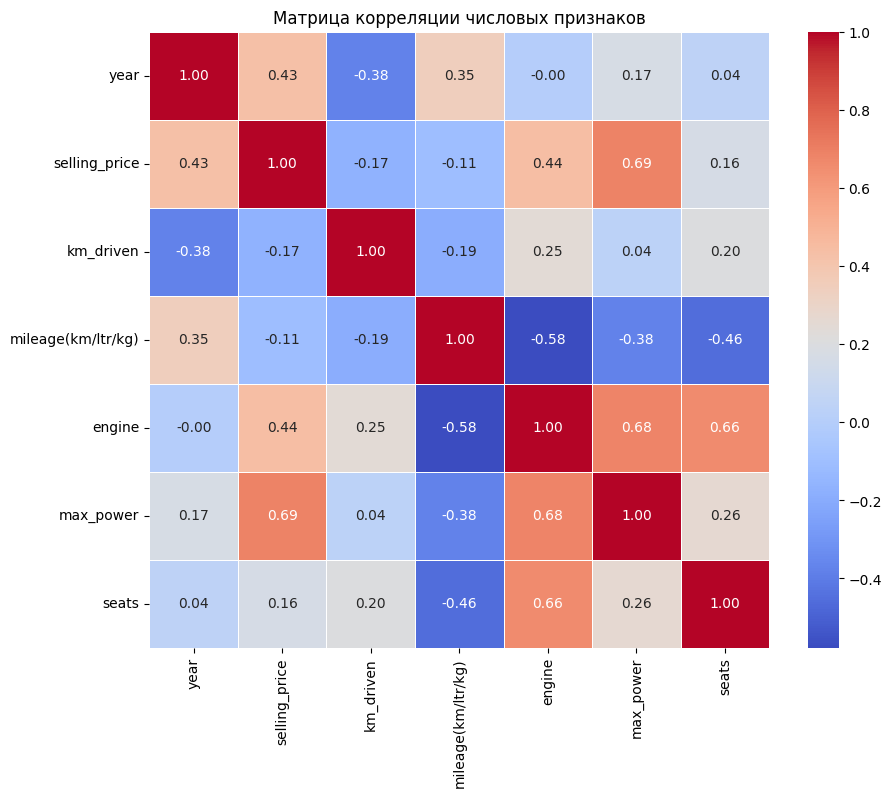

In [42]:
# Визуализация корреляционной матрицы с помощью тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

<h5>7. Краткие аналитические выводы по данным.</h5>

In [45]:
print("""
1. Структура и очистка данных:
   - Датасет содержит {0} строк и {1} столбцов.
   - Обнаружены пропуски в столбцах: mileage, engine, seats, max_power. Они заполнены медианой (числовые) или модой (категориальные).
   - Дубликаты удалены.

2. Анализ категориальных признаков:
   - Наиболее распространенный тип топлива: Дизель ({2} шт.) и Бензин ({3} шт.).
   - Большинство автомобилей с механической коробкой передач ({4} шт., {5:.1f}%).

3. Анализ цен:
   - Средняя цена автомобиля: {6:,.0f}.
   - Самый дорогой автомобиль: {7}.
   - Дизельные автомобили в среднем дороже ({8:,.0f}), чем бензиновые ({9:,.0f}).

4. Корреляционный анализ:
   - Сильная положительная корреляция между объемом двигателя (engine) и мощностью (max_power): {10:.2f}.
   - Цена (selling_price) умеренно коррелирует с годом выпуска (year): {11:.2f} и с мощностью (max_power): {12:.2f}.
   - Пробег (km_driven) слабо отрицательно коррелирует с ценой: {13:.2f} (чем больше пробег, тем ниже цена).
   - Объем двигателя и мощность — ключевые факторы, влияющие на стоимость автомобиля.
""".format(
    df.shape[0], df.shape[1],
    df['fuel'].value_counts().get('Diesel', 0),
    df['fuel'].value_counts().get('Petrol', 0),
    df['transmission'].value_counts().get('Manual', 0),
    df['transmission'].value_counts().get('Manual', 0) / len(df) * 100,
    df['selling_price'].mean(),
    df['selling_price'].max(),
    df[df['fuel'] == 'Diesel']['selling_price'].mean(),
    df[df['fuel'] == 'Petrol']['selling_price'].mean(),
    correlation_matrix.loc['engine', 'max_power'],
    correlation_matrix.loc['selling_price', 'year'],
    correlation_matrix.loc['selling_price', 'max_power'],
    correlation_matrix.loc['selling_price', 'km_driven']
))


1. Структура и очистка данных:
   - Датасет содержит 6926 строк и 12 столбцов.
   - Обнаружены пропуски в столбцах: mileage, engine, seats, max_power. Они заполнены медианой (числовые) или модой (категориальные).
   - Дубликаты удалены.

2. Анализ категориальных признаков:
   - Наиболее распространенный тип топлива: Дизель (3755 шт.) и Бензин (3077 шт.).
   - Большинство автомобилей с механической коробкой передач (6342 шт., 91.6%).

3. Анализ цен:
   - Средняя цена автомобиля: 517,271.
   - Самый дорогой автомобиль: 10000000.
   - Дизельные автомобили в среднем дороже (639,728), чем бензиновые (375,689).

4. Корреляционный анализ:
   - Сильная положительная корреляция между объемом двигателя (engine) и мощностью (max_power): 0.68.
   - Цена (selling_price) умеренно коррелирует с годом выпуска (year): 0.43 и с мощностью (max_power): 0.69.
   - Пробег (km_driven) слабо отрицательно коррелирует с ценой: -0.17 (чем больше пробег, тем ниже цена).
   - Объем двигателя и мощность — ключевые

<h5>Вывод: в ходе выполнения работы проведено исследование набора данных об автомобилях с использованием библиотеки Pandas. Определена структура данных, выявлены и обработаны пропуски и дубликаты. Выполнены операции фильтрации, сортировки, группировки и корреляционного анализа. Установлены ключевые факторы, влияющие на стоимость автомобилей на вторичном рынке.</h5>